# Analyze the two-dimensional metadynamics run

This notebook reads the OpenFerro HILLS file, treats the deposited collective-variable centers as a sampled trajectory, reconstructs the fixed-height Gaussian bias, and compares $-V_{\mathrm{meta}}(S_x,S_y)$ with the exactly known free-energy surface.

The collective variables are $S_x=\sum_r p_{r,x}$ and $S_y=\sum_r p_{r,y}$. They are observables owned by the simulation and are not separate terms in the physical Hamiltonian.

## Input and output paths

By default, the notebook reads output/HILLS. Set the environment variable OPENFERRO_METAD_OUTPUT before starting Jupyter to analyze another run, or edit output_directory below.

In [16]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


config_file = Path("config.json")
output_directory = Path("output")
hills_file = output_directory / "HILLS"
analysis_directory = output_directory / "analysis"
analysis_directory.mkdir(parents=True, exist_ok=True)

with config_file.open(encoding="utf-8") as stream:
    config = json.load(stream)

hills = np.loadtxt(hills_file, comments="#", ndmin=2)
if hills.shape[0] == 0 or hills.shape[1] != 6:
    raise ValueError("Expected a nonempty two-dimensional OpenFerro HILLS file.")

steps = hills[:, 0].astype(int)
centers_x = hills[:, 1]
centers_y = hills[:, 2]
sigma_x = hills[:, 3]
sigma_y = hills[:, 4]
hill_heights = hills[:, 5]
times_ps = steps * config["dynamics"]["dt"]

print(f"Loaded {len(hills)} hills from {hills_file}")
print(f"Trajectory duration: {times_ps[-1]:.3f} ps")
print(f"Hill interval: {config['metadynamics']['pace'] * config['dynamics']['dt']:.3f} ps")

Loaded 5000 hills from output/HILLS
Trajectory duration: 2000.000 ps
Hill interval: 0.400 ps


## Collective-variable trajectory

HILLS stores the updated CV position at each deposition. The plots below therefore show the trajectory sampled once per hill rather than once per MD step.

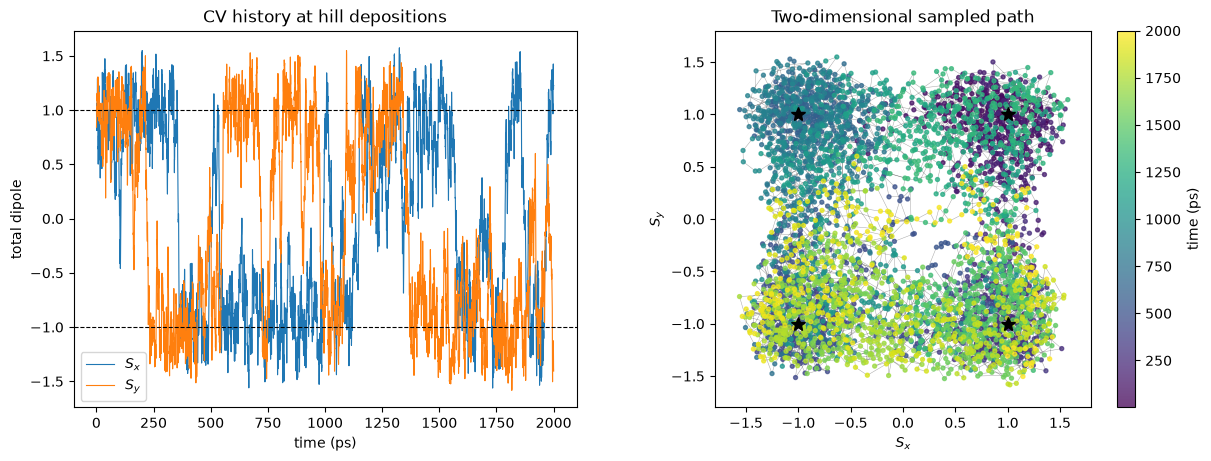

In [17]:
minimum = config["model"]["S0_P"]
lower_wall = np.asarray(config["metadynamics"]["lower_walls"]["at"])
upper_wall = np.asarray(config["metadynamics"]["upper_walls"]["at"])

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(times_ps, centers_x, linewidth=0.8, label="$S_x$")
axes[0].plot(times_ps, centers_y, linewidth=0.8, label="$S_y$")
axes[0].axhline(minimum, color="black", linestyle="--", linewidth=0.8)
axes[0].axhline(-minimum, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("time (ps)")
axes[0].set_ylabel("total dipole")
axes[0].set_title("CV history at hill depositions")
axes[0].legend()

trajectory = axes[1].scatter(
    centers_x,
    centers_y,
    c=times_ps,
    s=8,
    cmap="viridis",
    alpha=0.75,
)
axes[1].plot(centers_x, centers_y, color="0.65", linewidth=0.35, zorder=0)
for sign_x, sign_y in ((-1, -1), (-1, 1), (1, -1), (1, 1)):
    axes[1].plot(sign_x * minimum, sign_y * minimum, "k*", markersize=10)
axes[1].set_xlim(lower_wall[0], upper_wall[0])
axes[1].set_ylim(lower_wall[1], upper_wall[1])
axes[1].set_aspect("equal")
axes[1].set_xlabel("$S_x$")
axes[1].set_ylabel("$S_y$")
axes[1].set_title("Two-dimensional sampled path")
figure.colorbar(trajectory, ax=axes[1], label="time (ps)")

figure.savefig(analysis_directory / "cv_trajectory.png", dpi=180)
plt.show()

## Reconstruct the free-energy surface

For fixed-height classical metadynamics, the finite-time estimate is $\widehat F=-V_{\mathrm{meta}}$. The direct Gaussian sum below is independent of OpenFerro's private implementation. Exact and calculated surfaces are shifted separately so their minimum inside the predeclared comparison region is zero.

In [18]:
analysis = config["analysis"]
x_bounds, y_bounds = analysis["grid_bounds"]
grid_points = analysis["grid_points"]

x_values = np.linspace(x_bounds[0], x_bounds[1], grid_points)
y_values = np.linspace(y_bounds[0], y_bounds[1], grid_points)
x_grid, y_grid = np.meshgrid(x_values, y_values)

bias = np.zeros_like(x_grid)
for row in hills:
    _, center_x, center_y, width_x, width_y, height = row
    exponent = -0.5 * (
        ((x_grid - center_x) / width_x) ** 2
        + ((y_grid - center_y) / width_y) ** 2
    )
    bias += height * np.exp(exponent)

coefficient = config["model"]["A_eV_per_P4"]
exact_free_energy = coefficient * (
    (x_grid**2 - minimum**2) ** 2
    + (y_grid**2 - minimum**2) ** 2
)
calculated_free_energy = -bias

compare_x, compare_y = analysis["comparison_bounds"]
comparison_mask = (
    (x_grid >= compare_x[0])
    & (x_grid <= compare_x[1])
    & (y_grid >= compare_y[0])
    & (y_grid <= compare_y[1])
)

exact_free_energy -= np.min(exact_free_energy[comparison_mask])
calculated_free_energy -= np.min(calculated_free_energy[comparison_mask])
free_energy_error = calculated_free_energy - exact_free_energy

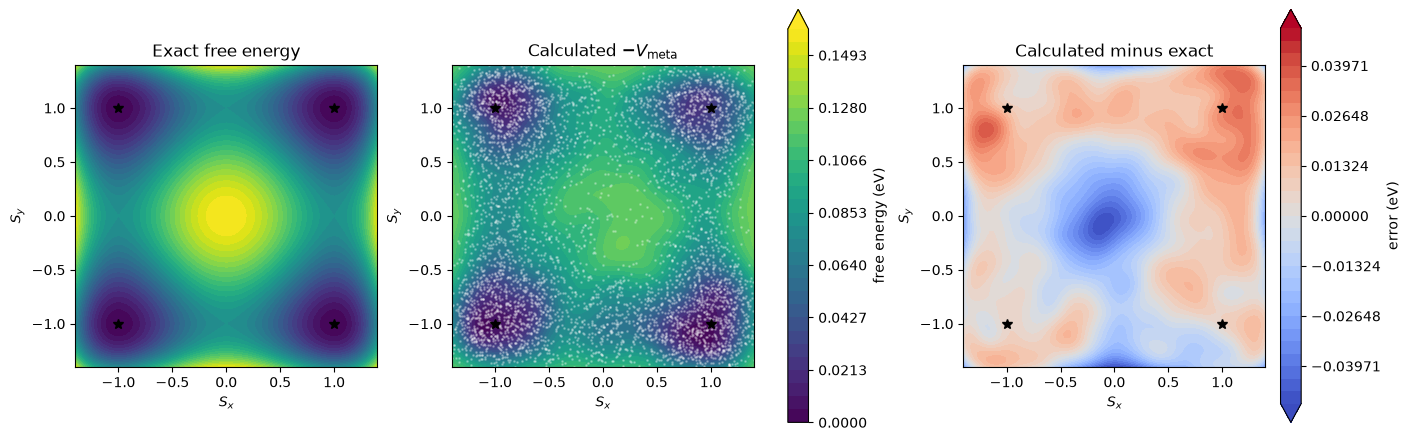

In [19]:
surface_maximum = max(
    np.max(exact_free_energy[comparison_mask]),
    np.max(calculated_free_energy[comparison_mask]),
)
surface_levels = np.linspace(0.0, surface_maximum, 31)
error_maximum = np.max(np.abs(free_energy_error[comparison_mask]))
error_levels = np.linspace(-error_maximum, error_maximum, 31)

figure, axes = plt.subplots(1, 3, figsize=(14, 4.3), constrained_layout=True)

exact_plot = axes[0].contourf(
    x_values,
    y_values,
    np.clip(exact_free_energy, 0.0, surface_maximum),
    levels=surface_levels,
    cmap="viridis",
    extend="max",
)
axes[0].set_title("Exact free energy")

calculated_plot = axes[1].contourf(
    x_values,
    y_values,
    np.clip(calculated_free_energy, 0.0, surface_maximum),
    levels=surface_levels,
    cmap="viridis",
    extend="max",
)
axes[1].scatter(centers_x, centers_y, s=1, color="white", alpha=0.25)
axes[1].set_title(r"Calculated $-V_{\mathrm{meta}}$")

error_plot = axes[2].contourf(
    x_values,
    y_values,
    np.clip(free_energy_error, -error_maximum, error_maximum),
    levels=error_levels,
    cmap="coolwarm",
    extend="both",
)
axes[2].set_title("Calculated minus exact")

for axis in axes:
    axis.set_xlim(compare_x)
    axis.set_ylim(compare_y)
    axis.set_aspect("equal")
    axis.set_xlabel("$S_x$")
    axis.set_ylabel("$S_y$")
    for sign_x, sign_y in ((-1, -1), (-1, 1), (1, -1), (1, 1)):
        axis.plot(sign_x * minimum, sign_y * minimum, "k*", markersize=7)

figure.colorbar(exact_plot, ax=axes[:2], label="free energy (eV)")
figure.colorbar(error_plot, ax=axes[2], label="error (eV)")
figure.savefig(analysis_directory / "free_energy_comparison.png", dpi=180)
plt.show()

## Accuracy and basin-visitation checks

In [20]:
axis_barrier = coefficient * minimum**4
rmse = float(np.sqrt(np.mean(free_energy_error[comparison_mask] ** 2)))
maximum_error = float(np.max(np.abs(free_energy_error[comparison_mask])))
normalized_rmse = rmse / axis_barrier

quadrant_order = ((-1, -1), (-1, 1), (1, -1), (1, 1))
reconstructed_minima = []
exact_minima = []
for sign_x, sign_y in quadrant_order:
    quadrant = (
        comparison_mask
        & (sign_x * x_grid > 0.0)
        & (sign_y * y_grid > 0.0)
    )
    if np.any(quadrant):
        flat_index = np.argmin(np.where(quadrant, calculated_free_energy, np.inf))
        index_y, index_x = np.unravel_index(flat_index, calculated_free_energy.shape)
        reconstructed_minima.append(
            (float(x_grid[index_y, index_x]), float(y_grid[index_y, index_x]))
        )
    else:
        reconstructed_minima.append((float("nan"), float("nan")))
    exact_minima.append((sign_x * minimum, sign_y * minimum))

minimum_errors = []
for reconstructed, exact in zip(reconstructed_minima, exact_minima):
    minimum_errors.append(
        float(np.linalg.norm(np.asarray(reconstructed) - np.asarray(exact)))
    )

axis_points = (
    (0.0, minimum),
    (0.0, -minimum),
    (minimum, 0.0),
    (-minimum, 0.0),
)
axis_values = []
for point_x, point_y in axis_points:
    index_x = int(np.argmin(np.abs(x_values - point_x)))
    index_y = int(np.argmin(np.abs(y_values - point_y)))
    axis_values.append(float(calculated_free_energy[index_y, index_x]))
estimated_axis_barrier = float(np.mean(axis_values))

center_x = int(np.argmin(np.abs(x_values)))
center_y = int(np.argmin(np.abs(y_values)))
estimated_central_barrier = float(calculated_free_energy[center_y, center_x])
axis_barrier_error = abs(estimated_axis_barrier - axis_barrier) / axis_barrier
central_barrier_error = (
    abs(estimated_central_barrier - 2.0 * axis_barrier)
    / (2.0 * axis_barrier)
)

both_signs_visited = bool(
    np.any(centers_x < 0.0)
    and np.any(centers_x > 0.0)
    and np.any(centers_y < 0.0)
    and np.any(centers_y > 0.0)
)
basin_radius = 0.5 * minimum
basins_visited = []
for sign_x, sign_y in quadrant_order:
    target = np.asarray((sign_x * minimum, sign_y * minimum))
    distances = np.linalg.norm(hills[:, 1:3] - target, axis=1)
    basins_visited.append(bool(np.any(distances <= basin_radius)))

grid_spacing = max(x_values[1] - x_values[0], y_values[1] - y_values[0])
minimum_tolerance = max(sigma_x[0], sigma_y[0]) + grid_spacing
passed = bool(
    normalized_rmse <= analysis["max_normalized_rmse"]
    and np.all(np.asarray(minimum_errors) <= minimum_tolerance)
    and axis_barrier_error <= analysis["max_barrier_relative_error"]
    and central_barrier_error <= analysis["max_barrier_relative_error"]
    and both_signs_visited
    and all(basins_visited)
)

metrics = {
    "passed": passed,
    "hill_count": int(len(hills)),
    "simulation_time_ps": float(times_ps[-1]),
    "rmse_eV": rmse,
    "maximum_absolute_error_eV": maximum_error,
    "normalized_rmse": normalized_rmse,
    "reconstructed_minima": reconstructed_minima,
    "minimum_location_errors": minimum_errors,
    "minimum_location_tolerance": float(minimum_tolerance),
    "estimated_axis_barrier_eV": estimated_axis_barrier,
    "exact_axis_barrier_eV": axis_barrier,
    "axis_barrier_relative_error": axis_barrier_error,
    "estimated_central_barrier_eV": estimated_central_barrier,
    "exact_central_barrier_eV": 2.0 * axis_barrier,
    "central_barrier_relative_error": central_barrier_error,
    "both_signs_visited": both_signs_visited,
    "basins_visited": basins_visited,
}

with (analysis_directory / "metrics.json").open("w", encoding="utf-8") as stream:
    json.dump(metrics, stream, indent=2)
    stream.write("\n")

np.savez(
    analysis_directory / "free_energy_surfaces.npz",
    x_values=x_values,
    y_values=y_values,
    exact_free_energy_eV=exact_free_energy,
    calculated_free_energy_eV=calculated_free_energy,
    error_eV=free_energy_error,
    comparison_mask=comparison_mask,
)

print(json.dumps(metrics, indent=2))

{
  "passed": false,
  "hill_count": 5000,
  "simulation_time_ps": 2000.0,
  "rmse_eV": 0.016285642111151816,
  "maximum_absolute_error_eV": 0.049641873928515476,
  "normalized_rmse": 0.2035705263893977,
  "reconstructed_minima": [
    [
      -1.104,
      -1.032
    ],
    [
      -0.9600000000000001,
      1.0559999999999998
    ],
    [
      0.9120000000000001,
      -1.104
    ],
    [
      0.8880000000000001,
      1.0559999999999998
    ]
  ],
  "minimum_location_errors": [
    0.10881176406988365,
    0.06881860213634083,
    0.13623509092741118,
    0.12521980673998803
  ],
  "minimum_location_tolerance": 0.143999997317791,
  "estimated_axis_barrier_eV": 0.08313472788399962,
  "exact_axis_barrier_eV": 0.08,
  "axis_barrier_relative_error": 0.03918409854999517,
  "estimated_central_barrier_eV": 0.11368231432297544,
  "exact_central_barrier_eV": 0.16,
  "central_barrier_relative_error": 0.2894855354814035,
  "both_signs_visited": true,
  "basins_visited": [
    true,
    true,

## Convergence with simulation time

The final check alone cannot establish convergence. The cells below repeat the reconstruction for the 300, 400, and 500 ps HILLS prefixes when they are available, then compare successive shifted surfaces inside the same fixed mask.

In [21]:
requested_times_ps = [300.0, 400.0, 500.0]
convergence_times_ps = [
    time_ps for time_ps in requested_times_ps if time_ps <= times_ps[-1] + 1e-12
]
if not convergence_times_ps or convergence_times_ps[-1] < times_ps[-1] - 1e-12:
    convergence_times_ps.append(float(times_ps[-1]))

prefix_surfaces = []
convergence_rows = []
for cutoff_ps in convergence_times_ps:
    prefix = hills[times_ps <= cutoff_ps + 1e-12]
    prefix_bias = np.zeros_like(x_grid)
    for row in prefix:
        _, center_x, center_y, width_x, width_y, height = row
        exponent = -0.5 * (
            ((x_grid - center_x) / width_x) ** 2
            + ((y_grid - center_y) / width_y) ** 2
        )
        prefix_bias += height * np.exp(exponent)

    prefix_surface = -prefix_bias
    prefix_surface -= np.min(prefix_surface[comparison_mask])
    prefix_surfaces.append(prefix_surface)
    prefix_error = prefix_surface - exact_free_energy

    prefix_basins = []
    for sign_x, sign_y in quadrant_order:
        target = np.asarray((sign_x * minimum, sign_y * minimum))
        distances = np.linalg.norm(prefix[:, 1:3] - target, axis=1)
        prefix_basins.append(bool(np.any(distances <= basin_radius)))

    convergence_rows.append(
        {
            "time_ps": float(cutoff_ps),
            "hill_count": int(len(prefix)),
            "normalized_rmse": float(
                np.sqrt(np.mean(prefix_error[comparison_mask] ** 2)) / axis_barrier
            ),
            "basins_visited": prefix_basins,
            "basin_count": int(sum(prefix_basins)),
        }
    )

surface_changes = []
for previous_time, current_time, previous_surface, current_surface in zip(
    convergence_times_ps[:-1],
    convergence_times_ps[1:],
    prefix_surfaces[:-1],
    prefix_surfaces[1:],
):
    surface_changes.append(
        {
            "from_time_ps": float(previous_time),
            "to_time_ps": float(current_time),
            "normalized_surface_rmse": float(
                np.sqrt(
                    np.mean(
                        (
                            current_surface[comparison_mask]
                            - previous_surface[comparison_mask]
                        )
                        ** 2
                    )
                )
                / axis_barrier
            ),
        }
    )

convergence = {
    "prefixes": convergence_rows,
    "successive_surface_changes": surface_changes,
}
with (analysis_directory / "convergence.json").open("w", encoding="utf-8") as stream:
    json.dump(convergence, stream, indent=2)
    stream.write("\n")

print(json.dumps(convergence, indent=2))

{
  "prefixes": [
    {
      "time_ps": 300.0,
      "hill_count": 750,
      "normalized_rmse": 0.4451242337955642,
      "basins_visited": [
        false,
        false,
        true,
        true
      ],
      "basin_count": 2
    },
    {
      "time_ps": 400.0,
      "hill_count": 1000,
      "normalized_rmse": 0.42283043014750266,
      "basins_visited": [
        true,
        false,
        true,
        true
      ],
      "basin_count": 3
    },
    {
      "time_ps": 500.0,
      "hill_count": 1250,
      "normalized_rmse": 0.4176329842615248,
      "basins_visited": [
        true,
        false,
        true,
        true
      ],
      "basin_count": 3
    },
    {
      "time_ps": 2000.0,
      "hill_count": 5000,
      "normalized_rmse": 0.2035705263893977,
      "basins_visited": [
        true,
        true,
        true,
        true
      ],
      "basin_count": 4
    }
  ],
  "successive_surface_changes": [
    {
      "from_time_ps": 300.0,
      "to_time_ps": 

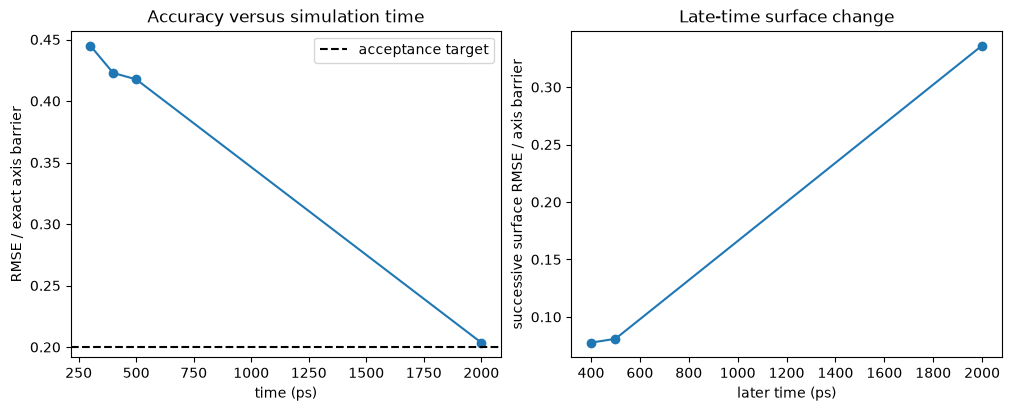

NOT CONVERGED


In [22]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axes[0].plot(
    [row["time_ps"] for row in convergence_rows],
    [row["normalized_rmse"] for row in convergence_rows],
    "o-",
)
axes[0].axhline(
    analysis["max_normalized_rmse"],
    color="black",
    linestyle="--",
    label="acceptance target",
)
axes[0].set_xlabel("time (ps)")
axes[0].set_ylabel("RMSE / exact axis barrier")
axes[0].set_title("Accuracy versus simulation time")
axes[0].legend()

if surface_changes:
    axes[1].plot(
        [row["to_time_ps"] for row in surface_changes],
        [row["normalized_surface_rmse"] for row in surface_changes],
        "o-",
    )
else:
    axes[1].text(0.5, 0.5, "Only one time point is available", ha="center")
axes[1].set_xlabel("later time (ps)")
axes[1].set_ylabel("successive surface RMSE / axis barrier")
axes[1].set_title("Late-time surface change")

figure.savefig(analysis_directory / "convergence.png", dpi=180)
plt.show()

print("PASS" if passed else "NOT CONVERGED")